In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    classification_report
)

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    has_xgb = True
except Exception:
    has_xgb = False

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete. XGBoost available:", has_xgb)

Setup complete. XGBoost available: True


In [62]:
def evaluate_model(y_true, y_pred, y_proba):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
    }
    return metrics

def plot_curves(y_true, y_proba, title_suffix=""):
    if y_proba is None:
        print("No probability scores available for curves.")
        return
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
    plt.title(f"ROC Curve {title_suffix}")
    plt.show()
    PrecisionRecallDisplay(precision=prec, recall=rec).plot()
    plt.title(f"Precision-Recall Curve {title_suffix}")
    plt.show()
def show_confusion(y_true, y_pred, title_suffix=""):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix {title_suffix}")
    plt.show()

In [63]:
def run_all_models(X, y, numeric_cols=None, dataset_name="Dataset"):
    models = {
        "LogisticRegression": LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
        ),
        "SVM_RBF": SVC(
            kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced_subsample"
        ),
    }
    if has_xgb:
        models["XGBoost"] = XGBClassifier(
            n_estimators=400, learning_rate=0.03, max_depth=4,
            subsample=0.9, colsample_bytree=0.8,
            eval_metric="logloss", random_state=RANDOM_STATE,
            tree_method="hist"
        )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    if numeric_cols is None:
        numeric_cols = list(range(X.shape[1]))

    scaler = ColumnTransformer(
        transformers=[("num", StandardScaler(), numeric_cols)],
        remainder="passthrough"
    )
    results = []
    best_model = None
    best_auc = -1
    for name, model in models.items():
        pipe = Pipeline([("scaler", scaler), ("clf", model)])
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        cv_auc = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc").mean()
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe.named_steps["clf"], "predict_proba") else None
        metrics = evaluate_model(y_test, y_pred, y_proba)
        metrics["cv_auc"] = cv_auc
        metrics["model"] = name
        results.append(metrics)
        print(f"\n=== {dataset_name} | {name} ===")
        print(classification_report(y_test, y_pred, digits=4))
        show_confusion(y_test, y_pred, f"({dataset_name} - {name})")
        plot_curves(y_test, y_proba, f"({dataset_name} - {name})")

        if metrics["roc_auc"] > best_auc:
            best_auc = metrics["roc_auc"]
            best_model = pipe
    results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
    return results_df, best_model, (X_train, X_test, y_train, y_test)


Synthetic Heart Dataset Shape: (1000, 14)
        age       sex        cp  trestbps      chol       fbs   restecg  \
0  0.224961  1.853798  0.574574 -5.045888  1.864981  0.320774  0.959913   
1  0.727019 -0.516239  0.859449  0.702759 -2.567493  0.887669  0.023354   
2  0.985085  2.474841 -3.902482 -2.678343  3.611289  0.354187  0.996366   
3  0.236190  1.229818  2.646268 -3.679584  0.025386  0.832554 -2.015759   
4 -0.264979  2.829950 -2.994197 -0.277984  0.778132 -1.277050  0.344925   

    thalach     exang   oldpeak     slope        ca      thal  target  
0 -0.651500  2.502775 -0.742575 -3.538800 -1.025058 -3.305618       1  
1  2.424649  2.352499 -1.394376  0.504485 -1.608099  0.306843       0  
2 -0.488585  4.470806 -0.195074 -3.024639 -1.086003 -0.243754       1  
3 -1.241332  1.241063 -2.465456 -1.323283 -0.070616  3.004198       0  
4  0.972129  1.542519 -1.068456 -2.309918 -1.005146  0.139985       0  
Class balance: target
0    0.548
1    0.452
Name: proportion, dtype: float6

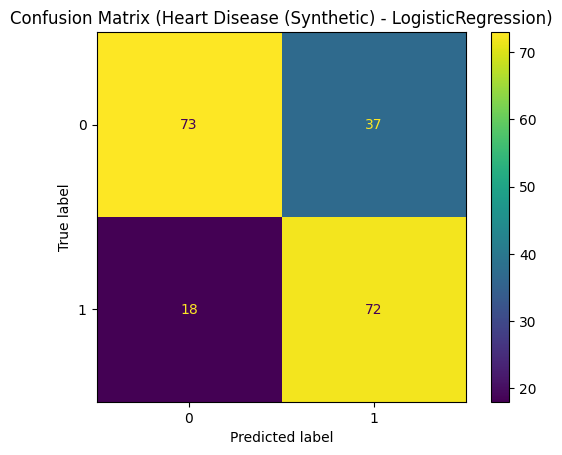

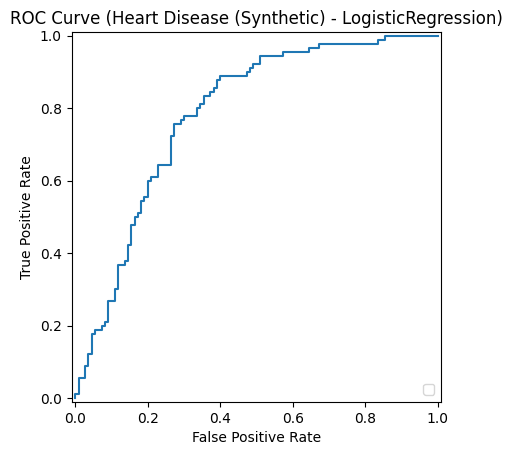

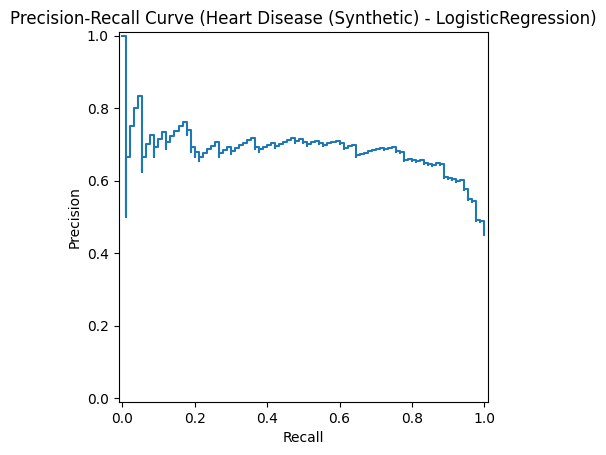


=== Heart Disease (Synthetic) | SVM_RBF ===
              precision    recall  f1-score   support

           0     0.9320    0.8727    0.9014       110
           1     0.8557    0.9222    0.8877        90

    accuracy                         0.8950       200
   macro avg     0.8939    0.8975    0.8946       200
weighted avg     0.8977    0.8950    0.8952       200



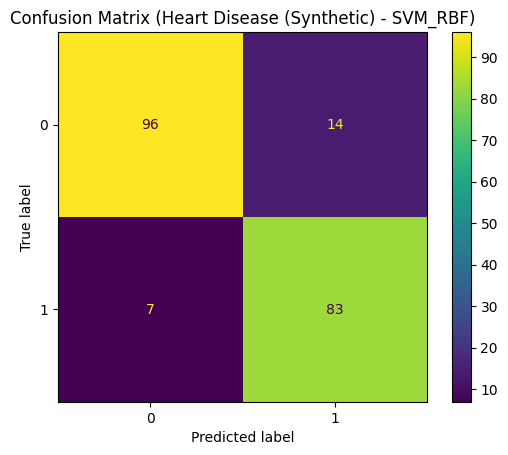

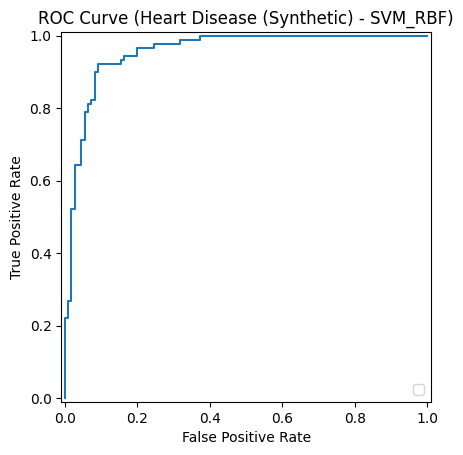

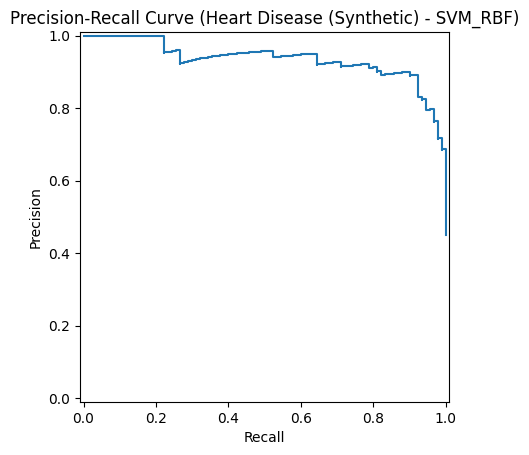


=== Heart Disease (Synthetic) | RandomForest ===
              precision    recall  f1-score   support

           0     0.8774    0.8455    0.8611       110
           1     0.8191    0.8556    0.8370        90

    accuracy                         0.8500       200
   macro avg     0.8483    0.8505    0.8490       200
weighted avg     0.8512    0.8500    0.8502       200



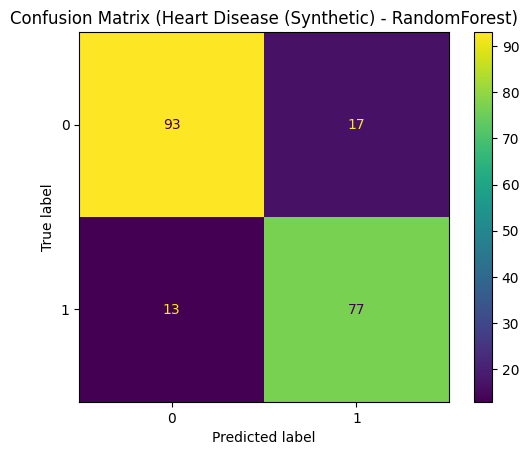

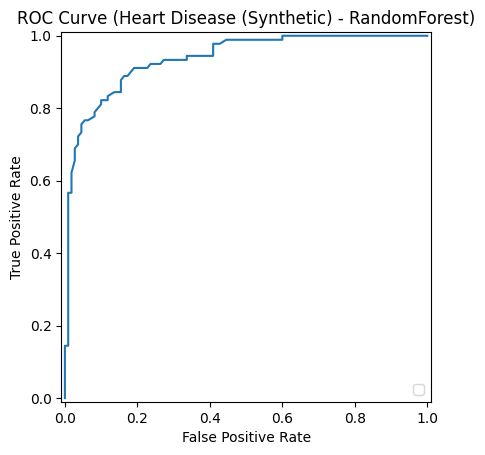

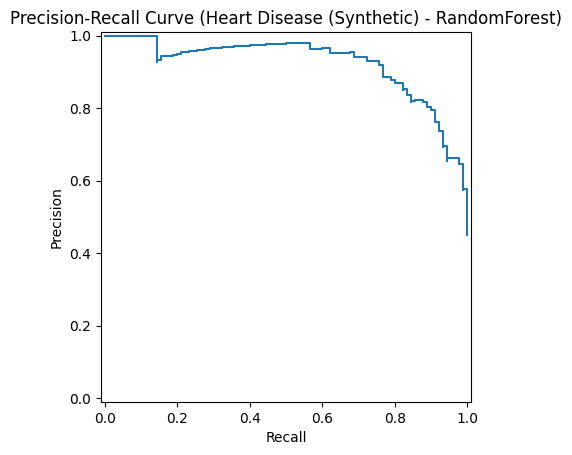


=== Heart Disease (Synthetic) | XGBoost ===
              precision    recall  f1-score   support

           0     0.8952    0.8545    0.8744       110
           1     0.8316    0.8778    0.8541        90

    accuracy                         0.8650       200
   macro avg     0.8634    0.8662    0.8642       200
weighted avg     0.8666    0.8650    0.8653       200



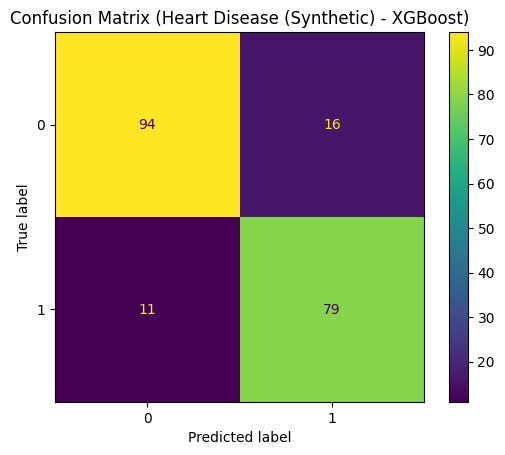

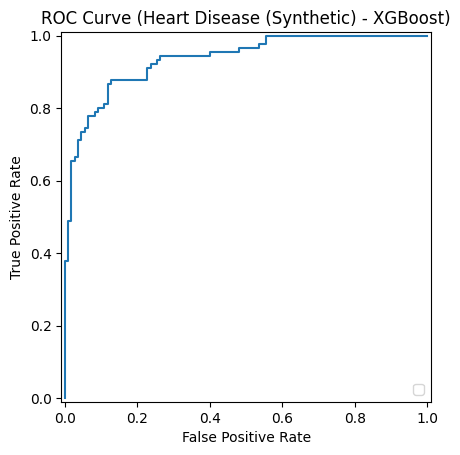

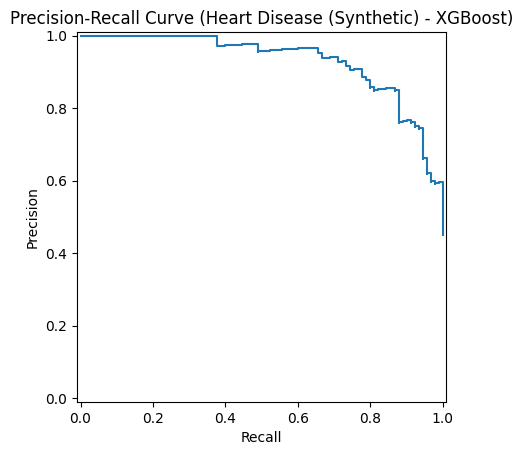

,accuracy,precision,recall,f1,roc_auc,cv_auc,model
1,0.895,0.855670,0.922222,0.887701,0.955354,0.959502,SVM_RBF
2,0.850,0.819149,0.855556,0.836957,0.937323,0.944300,RandomForest
3,0.865,0.831579,0.877778,0.854054,0.935152,0.941746,XGBoost
0,0.725,0.660550,0.800000,0.723618,0.782929,0.763599,LogisticRegression


In [64]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
X, y = make_classification(
    n_samples=1000,
    n_features=13,
    n_informative=8,
    n_redundant=2,
    n_classes=2,
    weights=[0.55, 0.45],
    random_state=42
)
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal"
]
heart = pd.DataFrame(X, columns=columns)
heart["target"] = y
X_heart = heart.drop(columns=["target"])
y_heart = heart["target"]
print("Synthetic Heart Dataset Shape:", heart.shape)
print(heart.head())
print("Class balance:", y_heart.value_counts(normalize=True).round(3))
results_heart, best_heart, splits_heart = run_all_models(
    X_heart, y_heart, dataset_name="Heart Disease (Synthetic)"
)
results_heart

Synthetic Diabetes Dataset Shape: (768, 9)
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0    -0.931483 -1.185781      -1.334161       0.095567 -0.283728  0.586797   
1    -0.636897  2.018458       2.053140       1.000118 -0.354769  0.109341   
2     0.265169  3.219979       0.731601       2.516353  0.931270  0.731910   
3     0.380744  0.291379      -0.504719       1.216222 -0.157037  1.853411   
4    -1.523127 -0.568370       0.873183       1.821027 -0.390923  0.242133   

   DiabetesPedigreeFunction       Age  Outcome  
0                  1.306625 -0.662790        0  
1                 -1.767319 -1.930928        1  
2                 -1.203660  1.522761        0  
3                  3.001561 -2.249065        0  
4                  2.996039 -3.827183        0  
Class balance: Outcome
0    0.647
1    0.353
Name: proportion, dtype: float64

=== Diabetes (Synthetic) | LogisticRegression ===
              precision    recall  f1-score   support

          

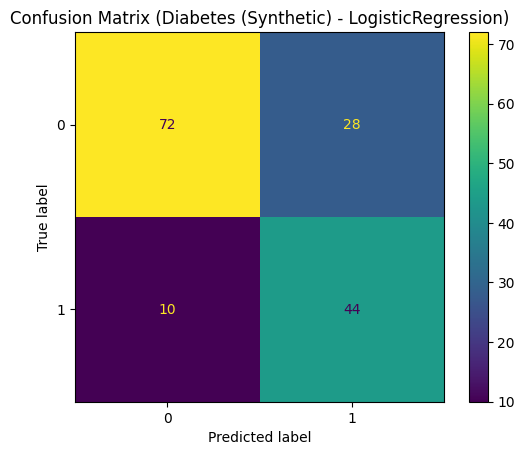

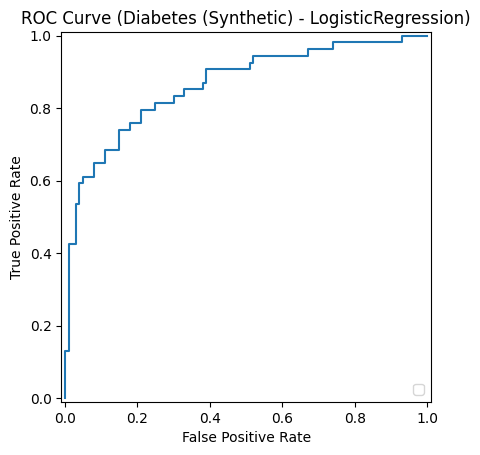

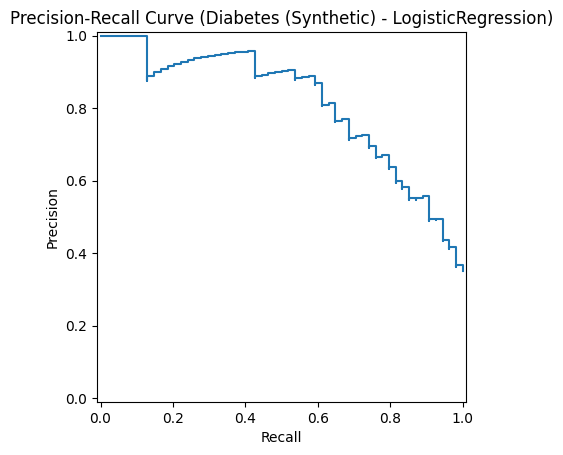


=== Diabetes (Synthetic) | SVM_RBF ===
              precision    recall  f1-score   support

           0     0.9583    0.9200    0.9388       100
           1     0.8621    0.9259    0.8929        54

    accuracy                         0.9221       154
   macro avg     0.9102    0.9230    0.9158       154
weighted avg     0.9246    0.9221    0.9227       154



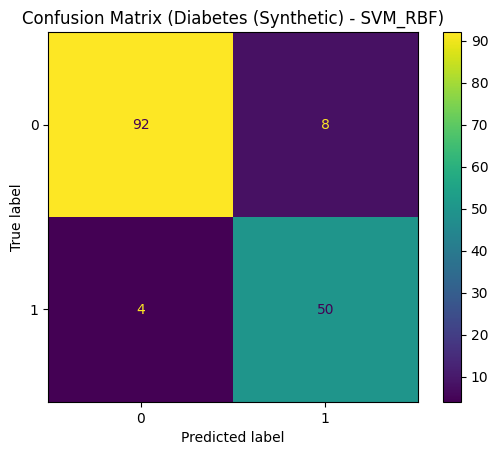

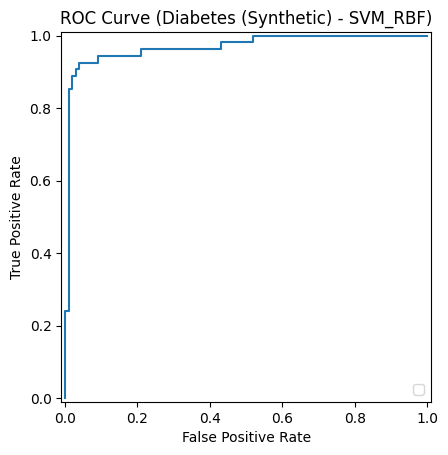

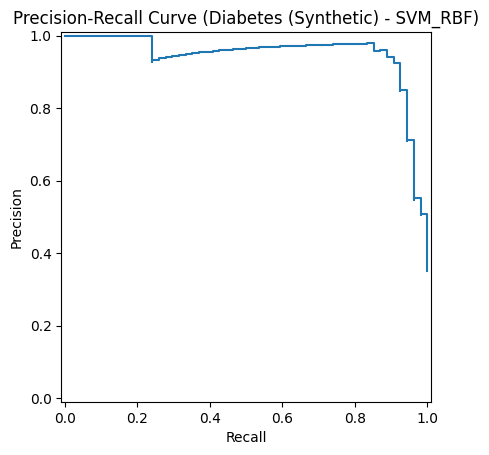


=== Diabetes (Synthetic) | RandomForest ===
              precision    recall  f1-score   support

           0     0.9505    0.9600    0.9552       100
           1     0.9245    0.9074    0.9159        54

    accuracy                         0.9416       154
   macro avg     0.9375    0.9337    0.9356       154
weighted avg     0.9414    0.9416    0.9414       154



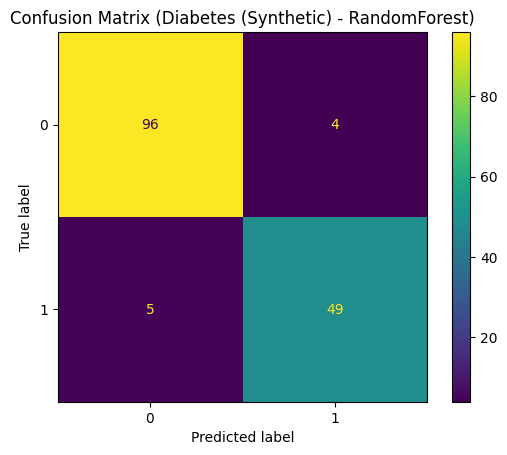

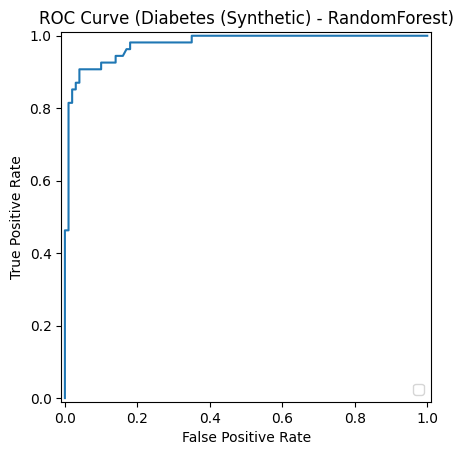

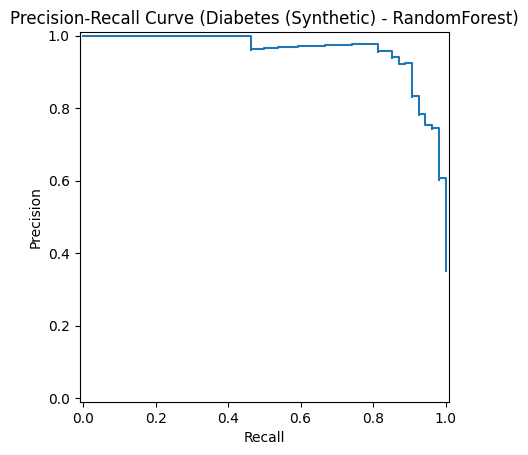


=== Diabetes (Synthetic) | XGBoost ===
              precision    recall  f1-score   support

           0     0.9394    0.9300    0.9347       100
           1     0.8727    0.8889    0.8807        54

    accuracy                         0.9156       154
   macro avg     0.9061    0.9094    0.9077       154
weighted avg     0.9160    0.9156    0.9158       154



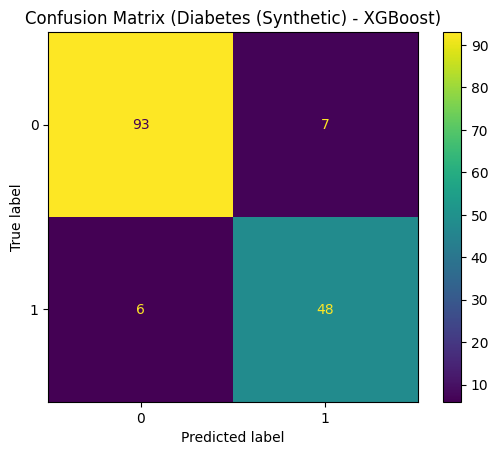

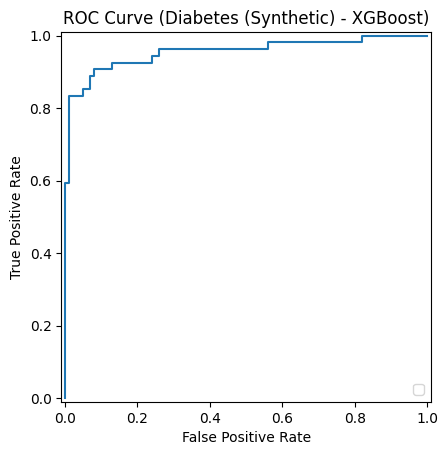

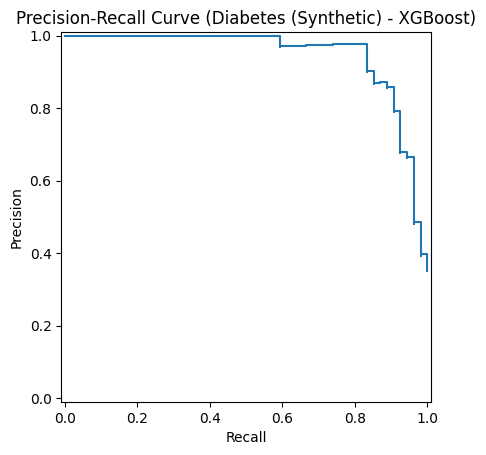

,accuracy,precision,recall,f1,roc_auc,cv_auc,model
2,0.941558,0.924528,0.907407,0.915888,0.976389,0.973143,RandomForest
1,0.922078,0.862069,0.925926,0.892857,0.968704,0.966917,SVM_RBF
3,0.915584,0.872727,0.888889,0.880734,0.955370,0.972335,XGBoost
0,0.753247,0.611111,0.814815,0.698413,0.863889,0.862537,LogisticRegression


In [65]:
from sklearn.datasets import make_classification
X, y = make_classification(
    n_samples=768,
    n_features=8,
    n_informative=5,
    n_redundant=0,
    n_classes=2,
    weights=[0.65, 0.35],
    random_state=42
)
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
dia = pd.DataFrame(X, columns=columns)
dia["Outcome"] = y
X_dia = dia.drop(columns=["Outcome"])
y_dia = dia["Outcome"]

print("Synthetic Diabetes Dataset Shape:", dia.shape)
print(dia.head())
print("Class balance:", y_dia.value_counts(normalize=True).round(3))
results_dia, best_dia, splits_dia = run_all_models(X_dia, y_dia,
dataset_name="Diabetes (Synthetic)")
results_dia

Breast Cancer Dataset Shape: (569, 30)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst t

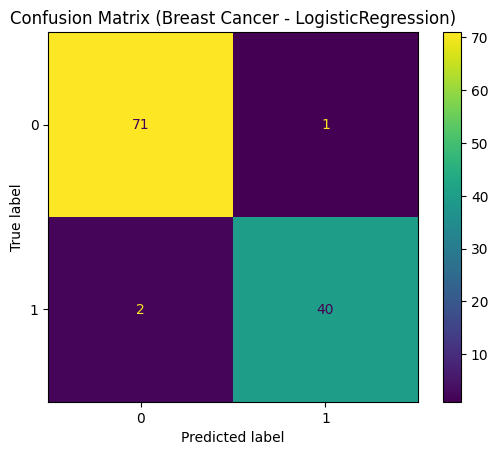

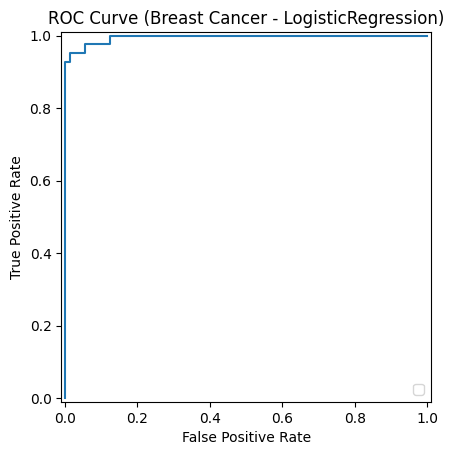

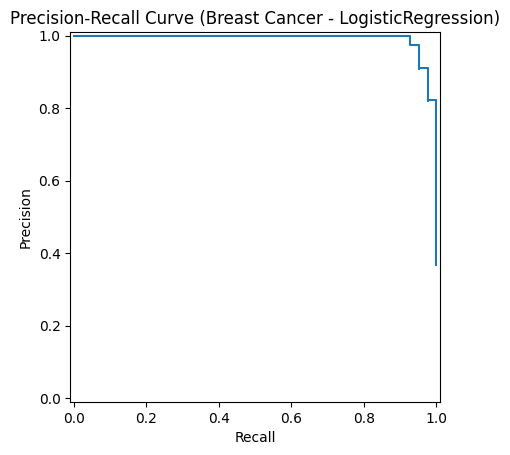


=== Breast Cancer | SVM_RBF ===
              precision    recall  f1-score   support

           0     0.9861    0.9861    0.9861        72
           1     0.9762    0.9762    0.9762        42

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



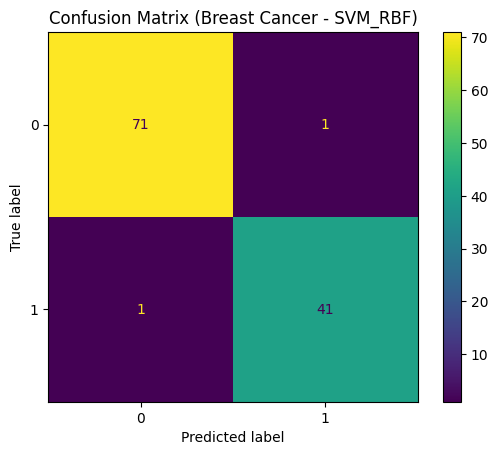

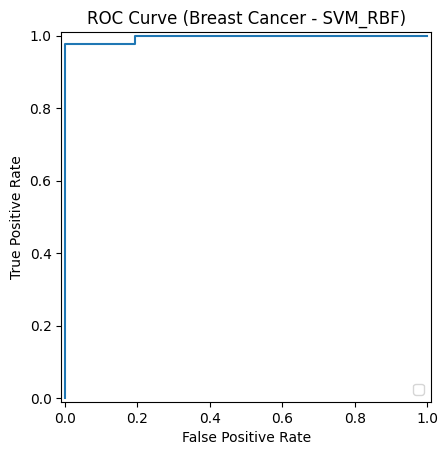

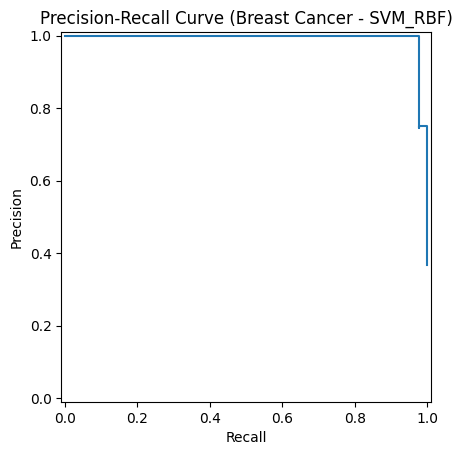


=== Breast Cancer | RandomForest ===
              precision    recall  f1-score   support

           0     0.9600    1.0000    0.9796        72
           1     1.0000    0.9286    0.9630        42

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0.9737    0.9735       114



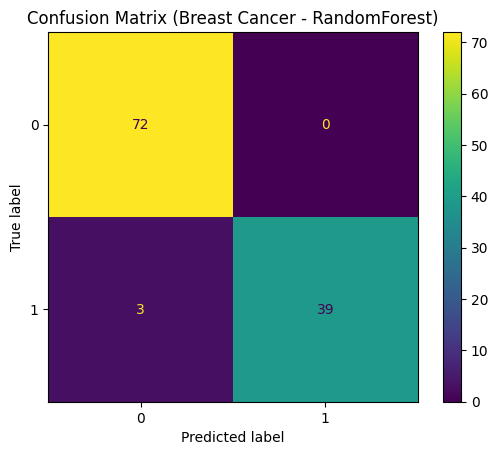

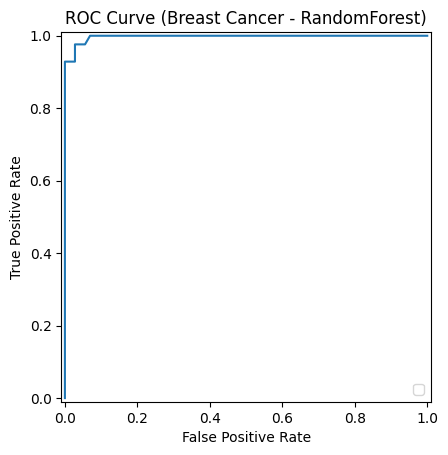

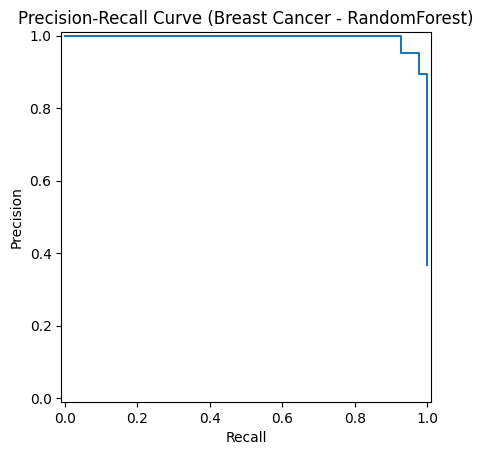


=== Breast Cancer | XGBoost ===
              precision    recall  f1-score   support

           0     0.9474    1.0000    0.9730        72
           1     1.0000    0.9048    0.9500        42

    accuracy                         0.9649       114
   macro avg     0.9737    0.9524    0.9615       114
weighted avg     0.9668    0.9649    0.9645       114



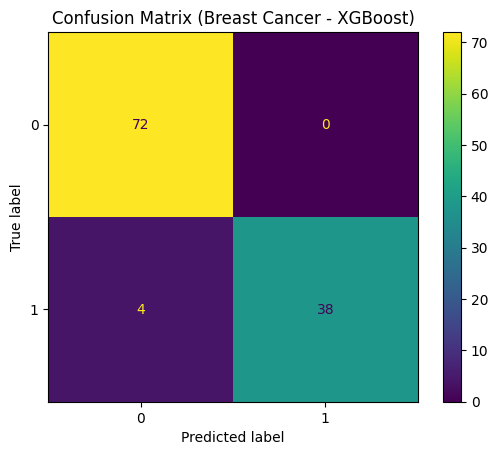

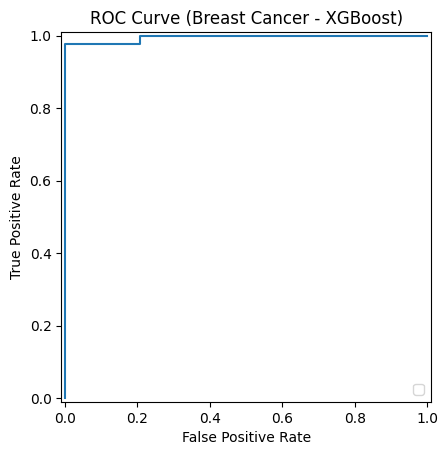

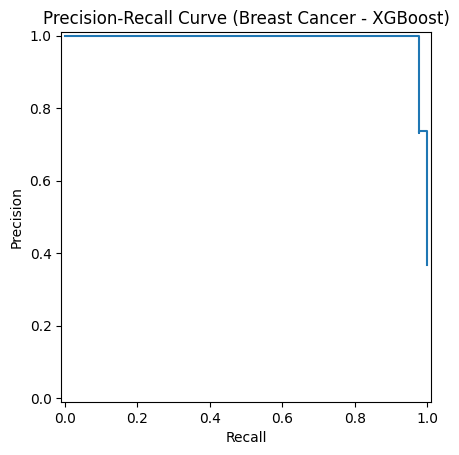

,accuracy,precision,recall,f1,roc_auc,cv_auc,model
2,0.973684,1.00000,0.928571,0.962963,0.997189,0.990107,RandomForest
1,0.982456,0.97619,0.976190,0.976190,0.995370,0.995511,SVM_RBF
0,0.973684,0.97561,0.952381,0.963855,0.995370,0.995052,LogisticRegression
3,0.964912,1.00000,0.904762,0.950000,0.995040,0.993578,XGBoost


In [66]:
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer(as_frame=True)
X_bc = bc.data
y_bc = pd.Series(bc.target, name="target")
y_bc = (y_bc == 0).astype(int)
print("Breast Cancer Dataset Shape:", X_bc.shape)
print(X_bc.head())
print("Class balance:", y_bc.value_counts(normalize=True).round(3))

results_bc, best_bc, splits_bc = run_all_models(
    X_bc, y_bc, dataset_name="Breast Cancer"
)
results_bc

In [67]:
def tidy(df, name):
 t = df.copy()
 t["dataset"] = name
 cols =["dataset","model","accuracy","precision","recall","f1","roc_auc","cv_auc"]
 return t[cols]
summary = pd.concat([
 tidy(results_heart, "Heart"),
 tidy(results_dia, "Diabetes"),
 tidy(results_bc, "BreastCancer"),
], ignore_index=True)
summary.sort_values(["dataset","roc_auc"], ascending=[True, False],
inplace=True)
summary.reset_index(drop=True, inplace=True)
summary

,dataset,model,accuracy,precision,recall,f1,roc_auc,cv_auc
0,BreastCancer,RandomForest,0.973684,1.000000,0.928571,0.962963,0.997189,0.990107
1,BreastCancer,SVM_RBF,0.982456,0.976190,0.976190,0.976190,0.995370,0.995511
2,BreastCancer,LogisticRegression,0.973684,0.975610,0.952381,0.963855,0.995370,0.995052
3,BreastCancer,XGBoost,0.964912,1.000000,0.904762,0.950000,0.995040,0.993578
4,Diabetes,RandomForest,0.941558,0.924528,0.907407,0.915888,0.976389,0.973143
5,Diabetes,SVM_RBF,0.922078,0.862069,0.925926,0.892857,0.968704,0.966917
6,Diabetes,XGBoost,0.915584,0.872727,0.888889,0.880734,0.955370,0.972335
7,Diabetes,LogisticRegression,0.753247,0.611111,0.814815,0.698413,0.863889,0.862537
8,Heart,SVM_RBF,0.895000,0.855670,0.922222,0.887701,0.955354,0.959502
9,Heart,RandomForest,0.850000,0.819149,0.855556,0.836957,0.937323,0.944300


In [68]:
def tree_importances(pipe, columns):
    clf = pipe.named_steps["clf"]
    if hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_
        return pd.Series(importances, index=columns).sort_values(ascending=False)
    else:
        return pd.Series(dtype=float)
print("\nHeart importances:")
print(tree_importances(best_heart, X_heart.columns).head(10))
print("\nDiabetes importances:")
print(tree_importances(best_dia, X_dia.columns).head(10))
print("\nBreast Cancer importances:")
print(tree_importances(best_bc, X_bc.columns).head(10))



Heart importances:
Series([], dtype: float64)

Diabetes importances:
DiabetesPedigreeFunction    0.236757
SkinThickness               0.214249
Age                         0.162633
Glucose                     0.153842
Pregnancies                 0.098684
BMI                         0.046623
BloodPressure               0.045383
Insulin                     0.041829
dtype: float64

Breast Cancer importances:
worst area              0.145097
worst perimeter         0.139145
worst concave points    0.103841
mean concave points     0.099572
worst radius            0.076424
mean radius             0.055852
mean perimeter          0.050868
mean concavity          0.045328
worst concavity         0.040676
mean area               0.039364
dtype: float64


In [69]:
import joblib
from pathlib import Path
Path("exports").mkdir(exist_ok=True)
joblib.dump(best_heart, "exports/heart_best_model.joblib")
joblib.dump(best_dia, "exports/diabetes_best_model.joblib")
joblib.dump(best_bc, "exports/breast_cancer_best_model.joblib")
print("Models saved to /content/exports (Colab) or ./exports (local machine).")


Models saved to /content/exports (Colab) or ./exports (local machine).
